# Notebook 04: Evaluación
## 4. Evaluación
**Objetivo**: Evaluación completa de cuatro modelos (Regresión Logística, Regresión Logística + WoE, Random Forest y XGBoost) sobre el conjunto de test, entrenados sobre las 28 variables que excluyen X53 y X48 (notebook 03).
Cálculo de AUC, KS, Gini, Exactitud y PPV a prevalencia real, matriz de confusión y calibración (diagrama de fiabilidad y Brier score). Comparativa directa con el benchmark de Mallo.

**Entradas**: ***data/test.csv*** + decisión de variables del notebook 03 + modelo WoE del notebook 03b.  
**Salidas**: tabla resumen comparativa con todas las métricas.

## 4.1 Importaciones

Se importan las librerías necesarias para la evaluación final y se establece la semilla de aleatoriedad.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
print("Librerias importadas correctamente.")

Librerias importadas correctamente.


## 4.2 Carga de particiones y entrenamiento de los modelos

Se cargan las tres particiones generadas en el notebook 02. Siguiendo la práctica habitual en el esquema de partición en tres conjuntos, las muestras de **train** y **validación** se combinan para el reentrenamiento final: una vez que la validación ha cumplido su función de comparar los modelos en los notebooks 03 y 03b, se incorpora al entrenamiento para que los modelos definitivos aprovechen todos los datos disponibles antes de medirse sobre **test**. El conjunto de test no ha intervenido en ninguna fase previa, por lo que proporciona una estimación insesgada del error de generalización. Este esquema reproduce el seguido por Mallo.

Conforme a la decisión tomada en el notebook 03, los modelos de esta evaluación final se entrenan sobre el conjunto de **28 variables que excluye X53 y X48**, identificadas como sospechosas de fuga de información. El conjunto completo de 30 variables no se reentrena aquí: su resultado ya quedó documentado en los notebooks 03 y 03b como referencia de lo que se obtendría sin ese control.

Se cargan las tres particiones y se combinan train y validación en un único conjunto de entrenamiento final, de modo que los modelos aprovechen todos los datos disponibles antes de evaluarse sobre test.

In [2]:
train = pd.read_csv("../data/train.csv")
val   = pd.read_csv("../data/val.csv")
test  = pd.read_csv("../data/test.csv")

# Reentrenamiento final: se combinan train y validación en un único conjunto
trainval = pd.concat([train, val], ignore_index=True)

# Conjunto de 28 variables (excluye X53 y X48, ver notebook 03)
VARS_FUGA = ["53_Porcentaje_Contratos_Incidencia", "48_Meses_Descubierto_12m"]
FEATURES = [c for c in trainval.columns if c != "Target_Impago" and c not in VARS_FUGA]
X_train, y_train = trainval[FEATURES], trainval["Target_Impago"]
X_test,  y_test  = test[FEATURES],  test["Target_Impago"]

# Peso del oversampling (igual que en el notebook 03): bueno=6, malo=1
PESO = 6
w_train = np.where(y_train == 0, PESO, 1)

print(f"Entrenamiento final (train + val): {X_train.shape[0]:,} obs | Test: {X_test.shape[0]:,} obs")
print(f"Variables empleadas: {len(FEATURES)} (excluidas: {VARS_FUGA})")

Entrenamiento final (train + val): 12,594 obs | Test: 4,198 obs
Variables empleadas: 28 (excluidas: ['53_Porcentaje_Contratos_Incidencia', '48_Meses_Descubierto_12m'])


A continuación se re-entrenan cuatro modelos sobre el conjunto completo (train + validación) con los mismos hiperparámetros del notebook 03: la Regresión Logística cruda (Flags + escalado), la Regresión Logística con WoE (la mejor versión lineal, según el notebook 03b), Random Forest y XGBoost. Se incluye la versión con WoE en la comparación principal, y no solo la cruda, para que el contraste con los modelos no lineales se haga frente al mejor modelo lineal disponible y no frente al más débil.

In [3]:
from optbinning import BinningProcess

# Definición de los modelos (mismos hiperparámetros que el notebook 03)
modelos = {
    "Regresión Logística": make_pipeline(
        StandardScaler(),
        LogisticRegression(solver="lbfgs", max_iter=5000, random_state=SEED)
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5,
        max_features="sqrt", random_state=SEED, n_jobs=1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=SEED, n_jobs=1, verbosity=0
    ),
}

# Entrenamiento sobre la muestra de train con el peso del oversampling
for nombre, modelo in modelos.items():
    if nombre == "Regresión Logística":
        modelo.fit(X_train, y_train, logisticregression__sample_weight=w_train)
    else:
        modelo.fit(X_train, y_train, sample_weight=w_train)
    print(f"  {nombre} entrenado.")

# Regresión Logística + WoE (mejor modelo lineal, notebook 03b): el tramado se aprende
# sobre el mismo conjunto train+val con el que se reentrenan los demás modelos.
binning = BinningProcess(FEATURES)
binning.fit(X_train.values, y_train.values)
X_train_woe = binning.transform(X_train.values, metric="woe")
X_test_woe  = binning.transform(X_test.values,  metric="woe")

rl_woe = LogisticRegression(max_iter=5000, random_state=SEED)
rl_woe.fit(X_train_woe, y_train, sample_weight=w_train)
print("  Regresión Logística + WoE entrenado.")

# Probabilidades de impago de los cuatro modelos sobre train y test, en un único diccionario
probs_train = {nombre: modelo.predict_proba(X_train)[:, 1] for nombre, modelo in modelos.items()}
probs_test  = {nombre: modelo.predict_proba(X_test)[:, 1]  for nombre, modelo in modelos.items()}
probs_train["Regresión Logística + WoE"] = rl_woe.predict_proba(X_train_woe)[:, 1]
probs_test["Regresión Logística + WoE"]  = rl_woe.predict_proba(X_test_woe)[:, 1]

# Orden de presentación en tablas y gráficos: del modelo lineal más simple al más complejo
ORDEN_MODELOS = ["Regresión Logística", "Regresión Logística + WoE", "Random Forest", "XGBoost"]

  Regresión Logística entrenado.


  Random Forest entrenado.


  XGBoost entrenado.


  Regresión Logística + WoE entrenado.


## 4.3 Métricas de evaluación: AUC, KS, Gini, Exactitud y PPV

Las tres primeras métricas miden lo mismo desde ángulos distintos: hasta qué punto el modelo asigna puntuaciones de riesgo más altas a los clientes que acaban impagando que a los que pagan.

- **AUC** (área bajo la curva ROC). Si se toma al azar un cliente malo y uno bueno, el AUC es la probabilidad de que el modelo le dé una puntuación de riesgo mayor al malo. Un AUC de 0,5 equivale a acertar como una moneda al aire, y 1 sería un modelo perfecto.

- **KS** (Kolmogorov-Smirnov). Mide cuánto separa el modelo a los dos grupos: si se dibujan las distribuciones de puntuaciones de buenos y malos, el KS es la máxima distancia entre ambas. Cuanto mayor es, menos se solapan las puntuaciones de pagadores e impagadores y más fácil resulta fijar un punto de corte que los distinga.

- **Gini** = 2 × AUC − 1. Es una reescritura del AUC al rango [0, 1], donde 0 es un modelo inútil y 1 uno perfecto. Es la métrica de uso más extendido en banca por convención del sector; al derivarse directamente del AUC, no aporta información nueva, sino una escala más habitual para el lector financiero.

Estas tres métricas son de **ranking**: dependen de cómo el modelo ordena a los clientes por riesgo, no de cuántos buenos y malos hay en la muestra, por lo que se pueden leer directamente sobre el test, aunque este conserve la proporción 1:2 del sobremuestreo (32,8% de malos) y no la de la cartera real (7,5%).

Eso no es así para todas las métricas. La proporción que se clasifica correctamente sobre el total, **la exactitud**, sí depende de cuántos buenos y malos hay en la muestra: cometer el mismo número de errores pesa menos sobre la exactitud cuanta más prevalencia tenga la clase mayoritaria. Calcularla directamente sobre el test 1:2 daría una cifra que no es la de la cartera real. Por eso, la exactitud y el **PPV** (la proporción de clientes marcados como impago que efectivamente lo son, *Positive Predictive Value*) se recalculan aquí a la prevalencia real de la cartera (92,47% buenos, 7,52% malos, notebook 01), aplicando los errores de Tipo I y Tipo II del test, que sí son comparables entre muestras, a esa proporción real.

Llega el momento de la prueba definitiva: se toman los cuatro modelos ya entrenados y se aplican sobre el conjunto de test, que no ha intervenido en su construcción, para comprobar cómo funcionan ante datos nuevos; es decir, si el modelo es generalizable. Para cada modelo se calculan las métricas de ranking (AUC, KS, Gini), los errores de clasificación y, a partir de ellos, la exactitud y el PPV a prevalencia real, y se añade el benchmark de Mallo como referencia para la comparativa directa.

In [4]:
# Prevalencia real de la cartera completa (notebook 01): 67.701 buenos, 5.509 malos
N_BUENOS_REAL = 67701
N_MALOS_REAL  = 5509
P_BUENO_REAL = N_BUENOS_REAL / (N_BUENOS_REAL + N_MALOS_REAL)
P_MALO_REAL  = N_MALOS_REAL  / (N_BUENOS_REAL + N_MALOS_REAL)

def metricas_completas(p_tr, p_te):
    auc_tr = roc_auc_score(y_train, p_tr)
    auc    = roc_auc_score(y_test,  p_te)
    fpr, tpr, _ = roc_curve(y_test, p_te)
    ks  = (tpr - fpr).max()
    pred = (p_te >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    error_I  = fp / (fp + tn)
    error_II = fn / (fn + tp)
    # Exactitud y PPV a prevalencia real: se extrapolan los errores del test (comparables
    # entre muestras) a la proporción real de buenos y malos de la cartera completa.
    exactitud_real = 1 - (error_I * P_BUENO_REAL + error_II * P_MALO_REAL)
    fp_real = error_I * N_BUENOS_REAL
    tp_real = (1 - error_II) * N_MALOS_REAL
    ppv_real = tp_real / (tp_real + fp_real)
    return {
        "AUC train": round(auc_tr, 4),
        "AUC test":  round(auc, 4),
        "KS test":   round(ks, 4),
        "Gini test": round(2 * auc - 1, 4),
        "Exactitud (cartera real)": round(exactitud_real, 4),
        "PPV (cartera real)":       round(ppv_real, 4),
        "Error I":   round(error_I, 4),
        "Error II":  round(error_II, 4),
    }

resultados = {nombre: metricas_completas(probs_train[nombre], probs_test[nombre]) for nombre in ORDEN_MODELOS}

# Benchmark de Mallo (diapositiva IV, mod12AIC). Su Error I (0,78%) y Error II (15,53%) ya están
# publicados; su exactitud (98,17%) solo es compatible con esos errores si se calculó a la
# prevalencia real de la cartera (ver verificación más abajo), por lo que es directamente
# comparable con la columna "Exactitud (cartera real)" de este trabajo, sin reescalar.
err_I_mallo, err_II_mallo = 0.0078, 0.1553
fp_real_mallo = err_I_mallo * N_BUENOS_REAL
tp_real_mallo = (1 - err_II_mallo) * N_MALOS_REAL
ppv_real_mallo = tp_real_mallo / (tp_real_mallo + fp_real_mallo)
resultados["Mallo (ref., valid.)"] = {
    "AUC train": 0.9789, "AUC test": 0.9758, "KS test": 0.8897,
    "Gini test": round(2 * 0.9758 - 1, 4),
    "Exactitud (cartera real)": 0.9817,
    "PPV (cartera real)": round(ppv_real_mallo, 4),
    "Error I": err_I_mallo, "Error II": err_II_mallo,
}
df_resultados = pd.DataFrame(resultados).T
print(df_resultados.to_string())

# Verificación: la exactitud publicada por Mallo (98,17%) solo se reproduce a prevalencia real
exactitud_mallo_real = 1 - (err_I_mallo * P_BUENO_REAL + err_II_mallo * P_MALO_REAL)
exactitud_mallo_12 = 1 - (err_I_mallo * (2/3) + err_II_mallo * (1/3))
print(f"\nVerificación exactitud de Mallo a prevalencia real:  {exactitud_mallo_real:.4f}")
print(f"Verificación exactitud de Mallo a una muestra 1:2:    {exactitud_mallo_12:.4f}")

                           AUC train  AUC test  KS test  Gini test  Exactitud (cartera real)  PPV (cartera real)  Error I  Error II
Regresión Logística           0.8845    0.8886   0.6325     0.7771                    0.9442              0.7525   0.0103    0.6158
Regresión Logística + WoE     0.9053    0.9133   0.6909     0.8267                    0.9526              0.8345   0.0074    0.5389
Random Forest                 0.9802    0.9397   0.7455     0.8794                    0.9628              0.8120   0.0124    0.3413
XGBoost                       0.9736    0.9422   0.7630     0.8843                    0.9667              0.8554   0.0092    0.3297
Mallo (ref., valid.)          0.9789    0.9758   0.8897     0.9516                    0.9817              0.8981   0.0078    0.1553

Verificación exactitud de Mallo a prevalencia real:  0.9811
Verificación exactitud de Mallo a una muestra 1:2:    0.9430


La tabla ofrece una primera lectura del rendimiento sobre test, ya sin X53 ni X48. XGBoost alcanza el mayor AUC (0,9422) y KS (0,7630), seguido de cerca por Random Forest (0,9397 y 0,7455). La Regresión Logística con WoE mejora con claridad a la versión cruda (AUC 0,9133 frente a 0,8886), confirmando sobre este conjunto reducido el mismo patrón que el notebook 03b documenta sobre el conjunto completo. Frente al benchmark de Mallo (AUC 0,9758, KS 0,8897), los cuatro modelos quedan por debajo: la diferencia no es ya una cuestión de qué modelo se emplea, sino del propio conjunto de variables, puesto que el benchmark de Mallo incluye X53 y X48.

Esto permite enunciar con precisión la ventaja de los modelos no lineales: frente al mejor modelo lineal disponible (Regresión Logística + WoE, AUC 0,9133), XGBoost mejora el AUC en 0,029 y Random Forest en 0,026. Esa cifra es mayor que la diferencia de apenas 0,01 que se observaba cuando X53 y X48 estaban presentes (notebook 03b), lo que indica que buena parte de la ventaja de los ensamblados, lejos de depender de la fuga de información, se manifiesta con más claridad una vez que esta se retira: sin una variable casi equivalente a la respuesta, la relación entre los predictores legítimos y el riesgo de impago es más compleja, y es ahí donde los modelos no lineales aportan más valor frente a una recta. El análisis detallado de cada propiedad y su interpretación de negocio se desarrolla en la sección 4.7.

### 4.3.1 ¿Es significativa la ventaja de los modelos no lineales? Test de DeLong

La sección anterior muestra que XGBoost y Random Forest superan en AUC a la Regresión Logística con WoE, y que XGBoost supera ligeramente a Random Forest. Antes de apoyar una recomendación en esas diferencias conviene comprobar si son estadísticamente significativas o si podrían deberse al azar de la muestra de test. El **test de DeLong** (DeLong, DeLong y Clarke-Pearson, 1988) está pensado precisamente para esto: compara los AUC de dos modelos evaluados sobre los mismos clientes, teniendo en cuenta que las dos puntuaciones están correlacionadas porque proceden de la misma muestra.

Se aplican dos comparaciones sobre el conjunto de test: XGBoost frente a la Regresión Logística + WoE (el mejor modelo lineal) y XGBoost frente a Random Forest. El resultado se calcula con la implementación rápida de DeLong (Sun y Xu, 2014) y se contrasta con un bootstrap de 5.000 remuestras sobre los mismos clientes, como comprobación independiente de que ambos métodos coinciden.

In [5]:
def compute_midrank(x):
    """Rango medio de cada valor (gestiona empates), paso intermedio del test de DeLong."""
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def fast_delong(predictions_sorted, label_1_count):
    """Implementación rápida de DeLong (Sun y Xu, 2014): AUCs y su matriz de covarianzas."""
    m = label_1_count
    n = predictions_sorted.shape[1] - m
    positivos = predictions_sorted[:, :m]
    negativos = predictions_sorted[:, m:]
    k = predictions_sorted.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)
    for r in range(k):
        tx[r, :] = compute_midrank(positivos[r, :])
        ty[r, :] = compute_midrank(negativos[r, :])
        tz[r, :] = compute_midrank(predictions_sorted[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / (2.0 * n)
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    cov = np.cov(v01) / m + np.cov(v10) / n
    return aucs, cov

def delong_compara(y_true, pred_a, pred_b):
    """Contraste de DeLong para dos modelos sobre la misma muestra: delta AUC, IC95% y p-valor."""
    y_true = np.asarray(y_true)
    orden = np.argsort(-y_true, kind="stable")
    m = int((y_true == 1).sum())
    preds = np.vstack([pred_a, pred_b])[:, orden]
    aucs, cov = fast_delong(preds, m)
    delta = aucs[0] - aucs[1]
    se = np.sqrt(cov[0, 0] + cov[1, 1] - 2 * cov[0, 1])
    z = delta / se
    p = 2 * (1 - scipy.stats.norm.cdf(abs(z)))
    return aucs, delta, se, p, (delta - 1.96 * se, delta + 1.96 * se)

def bootstrap_compara(y_true, pred_a, pred_b, n_boot=5000, seed=SEED):
    """Comprobación independiente del contraste anterior: bootstrap pareado sobre el mismo test."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    n = len(y_true)
    deltas = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        if y_true[idx].sum() in (0, n):
            deltas[i] = np.nan
            continue
        deltas[i] = roc_auc_score(y_true[idx], pred_a[idx]) - roc_auc_score(y_true[idx], pred_b[idx])
    deltas = deltas[~np.isnan(deltas)]
    return np.percentile(deltas, [2.5, 97.5])

import scipy.stats

comparaciones = [
    ("XGBoost", "Regresión Logística + WoE"),
    ("XGBoost", "Random Forest"),
]
for modelo_a, modelo_b in comparaciones:
    aucs, delta, se, p, (ci_low, ci_high) = delong_compara(y_test, probs_test[modelo_a], probs_test[modelo_b])
    ci_low_boot, ci_high_boot = bootstrap_compara(y_test.values, probs_test[modelo_a], probs_test[modelo_b])
    print(f"{modelo_a} vs {modelo_b}")
    print(f"  AUC {modelo_a} = {aucs[0]:.4f}  |  AUC {modelo_b} = {aucs[1]:.4f}  |  delta AUC = {delta:.4f}")
    print(f"  DeLong:    IC95% = [{ci_low:.4f}, {ci_high:.4f}]   p = {p:.4g}")
    print(f"  Bootstrap: IC95% = [{ci_low_boot:.4f}, {ci_high_boot:.4f}]  (comprobación independiente)")
    print()

XGBoost vs Regresión Logística + WoE
  AUC XGBoost = 0.9422  |  AUC Regresión Logística + WoE = 0.9133  |  delta AUC = 0.0288
  DeLong:    IC95% = [0.0232, 0.0344]   p = 0
  Bootstrap: IC95% = [0.0234, 0.0344]  (comprobación independiente)



XGBoost vs Random Forest
  AUC XGBoost = 0.9422  |  AUC Random Forest = 0.9397  |  delta AUC = 0.0025
  DeLong:    IC95% = [-0.0006, 0.0055]   p = 0.1157
  Bootstrap: IC95% = [-0.0006, 0.0054]  (comprobación independiente)



Los dos métodos coinciden. Frente a la Regresión Logística + WoE, la ventaja de XGBoost (0,0288 de AUC) es estadísticamente significativa: el intervalo de confianza al 95% va de 0,023 a 0,034 y no incluye el cero, con un p-valor muy por debajo de 0,001. Frente a Random Forest, en cambio, la diferencia (0,0025 de AUC) no lo es: el intervalo de confianza incluye el cero (de -0,001 a 0,006) y el p-valor es 0,12, muy por encima del umbral habitual de 0,05.

En términos prácticos, esto significa que XGBoost y Random Forest son indistinguibles en capacidad discriminante sobre este conjunto de test, y que la recomendación de XGBoost frente a Random Forest no puede apoyarse en el AUC, sino que debe justificarse por otras propiedades en las que sí difieren: el menor Error de Tipo II (33,0% frente a 34,1%) y la calibración, analizada en la sección 4.7.

## 4.4 Curvas ROC finales (test)

El gráfico que ilustra el rendimiento final compara las curvas ROC de los tres modelos sobre el conjunto de test, con los AUC definitivos.

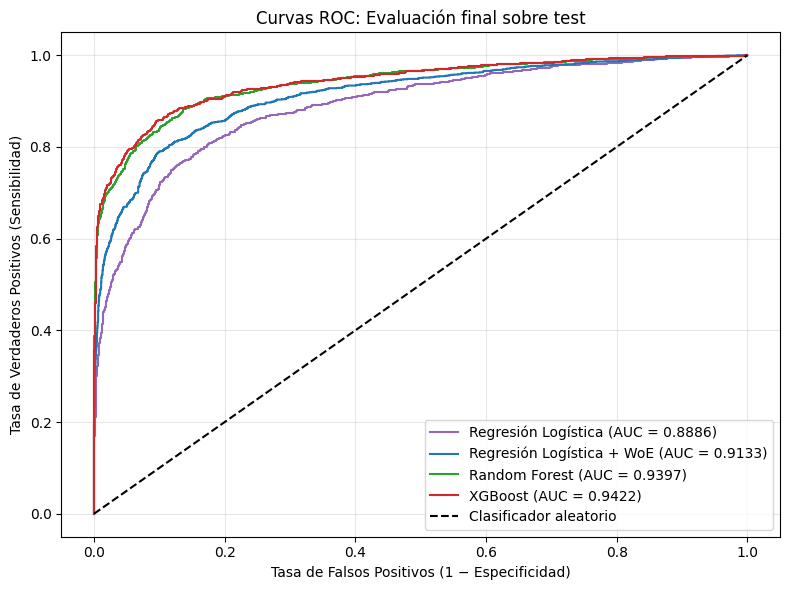

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

colores = {
    "Regresión Logística":        "#9467bd",
    "Regresión Logística + WoE":  "#1f77b4",
    "Random Forest":              "#2ca02c",
    "XGBoost":                    "#d62728",
}

for nombre in ORDEN_MODELOS:
    prob = probs_test[nombre]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.4f})", color=colores[nombre])

ax.plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos (1 − Especificidad)")
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
ax.set_title("Curvas ROC: Evaluación final sobre test")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/04_curvas_ROC_test.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.5 Matrices de confusión

La **matriz de confusión** cruza la predicción del modelo con el resultado realmente observado, repartiendo a los clientes de test en cuatro casillas. Tomando como clase de interés el impago, esas casillas son:

- **Verdaderos negativos (VN):** clientes buenos que el modelo clasifica como buenos. Acierto.
- **Verdaderos positivos (VP):** clientes impagadores que el modelo detecta como tales. Acierto.
- **Falsos positivos (FP):** clientes buenos que el modelo marca por error como impagadores. Es el **error de Tipo I**, la entidad rechaza a alguien que habría pagado (coste de oportunidad).
- **Falsos negativos (FN):** clientes impagadores que el modelo deja pasar como buenos. Es el **error de Tipo II**, se concede el préstamo a alguien que acaba sin pagar (pérdida directa, el error más caro para el banco).

Un buen modelo concentra a casi todos los clientes en la diagonal de aciertos (VN y VP) y deja casi vacías las dos casillas de error.

A continuación se calculan y representan las matrices de confusión de los tres modelos sobre test, usando un umbral de clasificación de 0,5.

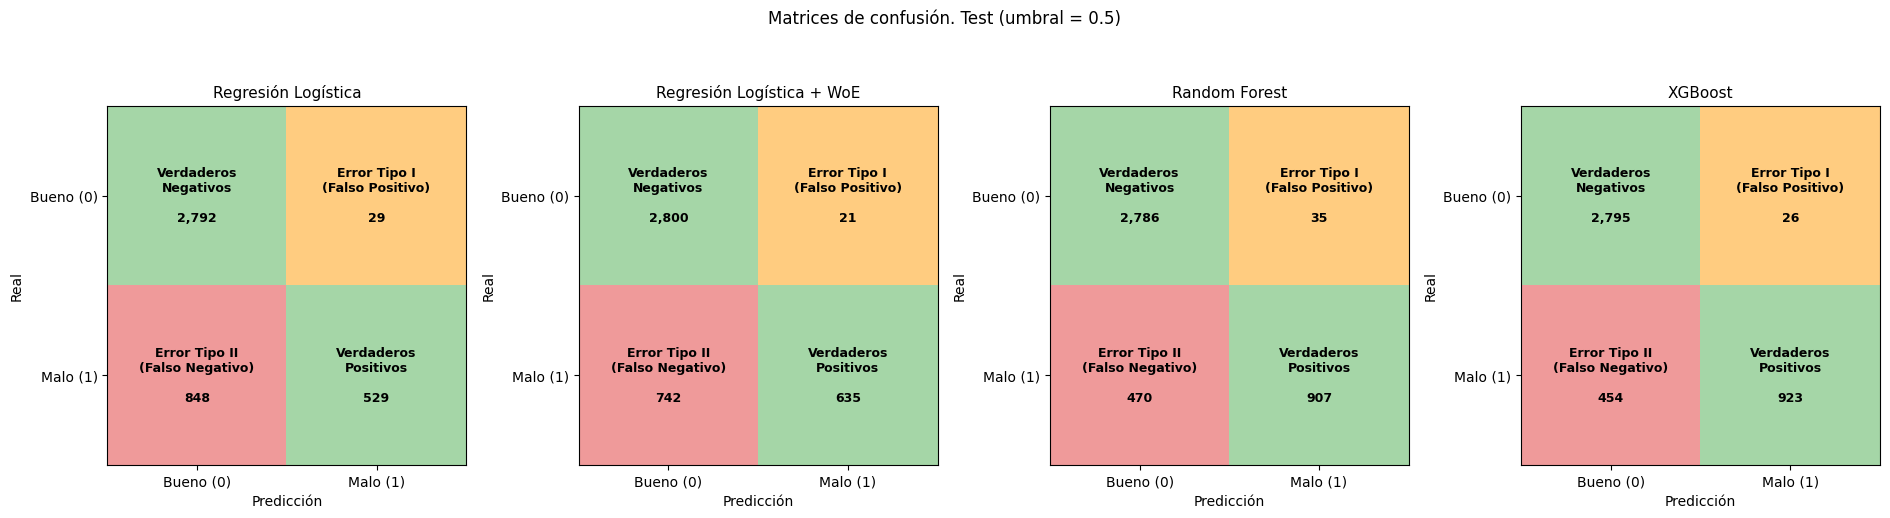

In [7]:
from matplotlib.colors import to_rgb

UMBRAL = 0.5

# Un color por tipo de casilla, para distinguir aciertos de cada tipo de error
C_ACIERTO  = to_rgb("#A5D6A7")  # verde: clasificación correcta
C_ERROR_I  = to_rgb("#FFCC80")  # naranja: Error Tipo I (falso positivo)
C_ERROR_II = to_rgb("#EF9A9A")  # rojo: Error Tipo II (falso negativo, el más costoso)

fig, axes = plt.subplots(1, 4, figsize=(19, 5))

for ax, nombre in zip(axes, ORDEN_MODELOS):
    prob = probs_test[nombre]
    pred = (prob >= UMBRAL).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    # Color de fondo de cada casilla (filas = clase real, columnas = predicción)
    colores = np.array([
        [C_ACIERTO,  C_ERROR_I],   # Real Bueno: VN, FP
        [C_ERROR_II, C_ACIERTO],   # Real Malo:  FN, VP
    ])
    ax.imshow(colores, aspect="equal")

    # Etiqueta y recuento dentro de cada casilla
    etiquetas = [
        [f"Verdaderos\nNegativos\n\n{tn:,}", f"Error Tipo I\n(Falso Positivo)\n\n{fp:,}"],
        [f"Error Tipo II\n(Falso Negativo)\n\n{fn:,}", f"Verdaderos\nPositivos\n\n{tp:,}"],
    ]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, etiquetas[i][j], ha="center", va="center",
                    fontsize=9, fontweight="bold")

    ax.set_xticks([0, 1]); ax.set_xticklabels(["Bueno (0)", "Malo (1)"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Bueno (0)", "Malo (1)"])
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    ax.set_title(nombre, fontsize=11)

plt.suptitle(f"Matrices de confusión. Test (umbral = {UMBRAL})", y=1.03)
plt.tight_layout()
plt.savefig("../reports/figures/04_matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Extrapolación a la cartera real: los recuentos de test están en una muestra 1:2
# (2.821 buenos, 1.377 malos), muy distinta a la proporción real (67.701 buenos, 5.509 malos).
# Se aplican los errores de Tipo I y Tipo II, que sí son comparables entre muestras, al tamaño
# real de cada clase para estimar cuántos casos se clasificarían mal sobre la cartera completa.
filas_real = {}
for nombre in ORDEN_MODELOS:
    pred = (probs_test[nombre] >= UMBRAL).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    error_I, error_II = fp / (fp + tn), fn / (fn + tp)
    fp_real = error_I * N_BUENOS_REAL
    fn_real = error_II * N_MALOS_REAL
    filas_real[nombre] = {
        "Buenos rechazados (FP)":   round(fp_real),
        "Impagos no detectados (FN)": round(fn_real),
    }
tabla_cartera_real = pd.DataFrame(filas_real).T
print(f"Extrapolación a la cartera real ({N_BUENOS_REAL:,} buenos, {N_MALOS_REAL:,} malos):")
print(tabla_cartera_real.to_string())

Extrapolación a la cartera real (67,701 buenos, 5,509 malos):
                           Buenos rechazados (FP)  Impagos no detectados (FN)
Regresión Logística                           696                        3393
Regresión Logística + WoE                     504                        2969
Random Forest                                 840                        1880
XGBoost                                       624                        1816


Las cuatro matrices se construyen sobre los mismos 4.198 clientes de test (2.821 buenos y 1.377 impagadores), proporción que reproduce el 1:2 del sobremuestreo y no la de la cartera real. La diferencia entre modelos está sobre todo en los falsos negativos, es decir, en los impagadores que cada modelo deja pasar como buenos:

- **Regresión Logística (cruda):** detecta 529 de los 1.377 impagadores y se le escapan 848 (error de Tipo II del 61,6%). Rechaza por error a 29 clientes buenos (error de Tipo I del 1,0%). Sin X53 y X48, el modelo lineal sin WoE pierde la mayor parte de su capacidad de clasificación.
- **Regresión Logística + WoE:** mejora hasta 635 impagadores detectados, 742 sin detectar (53,9%), con 21 falsos positivos (0,7%).
- **Random Forest:** detecta 907 impagadores, deja pasar 470 (34,1%), con 35 falsos positivos (1,2%).
- **XGBoost:** es el que menos impagadores deja pasar, 454 de 1.377 (33,0%), con 26 falsos positivos (0,9%).

El patrón es el mismo que ya mostraba el notebook 03 sin X53 y X48: los modelos no lineales mantienen una ventaja clara sobre ambas versiones de la Regresión Logística, y XGBoost vuelve a ser el más equilibrado, aunque el error de Tipo II de los cuatro modelos ha subido sustancialmente frente a los valores que se obtenían con X53 y X48 incluidas.

**Lectura sobre la cartera real.** Estos recuentos están sobre una muestra 1:2, muy distinta a la proporción real de 67.701 buenos y 5.509 malos (12,3:1). Aplicando los errores de Tipo I y Tipo II, que sí son comparables entre muestras, al tamaño real de cada clase, XGBoost rechazaría por error a unos 624 buenos clientes y dejaría sin detectar unos 1.816 impagos; Random Forest, unos 840 y 1.880 respectivamente; la Regresión Logística con WoE, unos 504 y 2.969. El recuento bruto del test ("26 frente a 454") subestima mucho el volumen real de la operación; la magnitud que importa para la entidad es la de la cartera completa.

### Comparación con el modelo de Mallo

Mallo no publica la matriz de confusión en recuentos, sino las tasas de error sobre su muestra de validación (Tabla 5.6 de las diapositivas), por lo que la comparación se establece en porcentaje. Su modelo es una regresión logística (mod12AIC) con WoE, comparable con la Regresión Logística + WoE de este trabajo, salvo porque su conjunto de variables incluye X53 y X48 y el de aquí no:

| Modelo | Error Tipo I | Error Tipo II |
|--------|:---:|:---:|
| Regresión Logística | 1,0% | 61,6% |
| Regresión Logística + WoE | 0,7% | 53,9% |
| Random Forest | 1,2% | 34,1% |
| XGBoost | 0,9% | 33,0% |
| Mallo, mod12AIC (validación, con X53 y X48) | 0,8% | 15,5% |

*Nota: la fila de Mallo procede de su muestra de validación, no de un conjunto de test independiente como las cuatro restantes; ambas muestras son, no obstante, estadísticamente equivalentes (misma población y tamaño relativo). La comparación con esta fila debe leerse, sobre todo, como el efecto de incluir o excluir X53 y X48, no como una diferencia de modelo o de muestra.*

Con X53 y X48 fuera del conjunto, el error de Tipo II sube de forma marcada en los cuatro modelos frente al 15,5% de Mallo: del 61,6% de la Regresión Logística cruda al 33,0% de XGBoost. La jerarquía entre modelos se mantiene (los no lineales superan a los lineales, y la versión WoE mejora a la cruda), pero el nivel absoluto de los cuatro queda por debajo de la referencia, precisamente porque esa referencia se apoya en las dos variables que el notebook 03 identifica como sospechosas de fuga. El error de Tipo I, en cambio, se mantiene contenido y similar entre todos los modelos (entre el 0,7% y el 1,2%), lo que indica que la pérdida de capacidad discriminante afecta sobre todo a la detección de impagos, no a la tasa de rechazo de buenos clientes.

## 4.6 Sensibilidad al umbral de decisión

Las matrices de confusión anteriores emplean el umbral por defecto de 0,5: se clasifica como impago a todo cliente cuya probabilidad estimada supere ese valor. Sin embargo, en credit scoring los dos tipos de error no tienen el mismo coste. Un **error de Tipo II** (conceder el préstamo a un cliente que finalmente impaga) genera una pérdida directa para la entidad, mientras que un **error de Tipo I** (rechazar a un cliente que habría pagado) supone un coste de oportunidad menor. Conviene, por tanto, examinar cómo se comporta el modelo al desplazar el umbral.

La siguiente tabla recoge, para el modelo XGBoost sobre test, las métricas a distintos umbrales, incluido el **umbral de Youden**. Este umbral es el que mejor separa a los dos grupos de clientes: se define como el punto que maximiza la suma de sensibilidad (proporción de impagadores detectados) y especificidad (proporción de buenos clientes correctamente aceptados), o lo que es lo mismo, el que maximiza la diferencia entre la tasa de verdaderos positivos y la de falsos positivos. Geométricamente es el punto de la curva ROC más alejado de la diagonal del clasificador aleatorio, y coincide con el punto donde se mide el estadístico KS. A diferencia del 0,5 por defecto, no es un valor fijo, sino que lo determinan los propios datos.

In [9]:
from sklearn.metrics import confusion_matrix

p_xgb = probs_test["XGBoost"]

# Umbral de Youden (equivale al punto KS): maximiza sensibilidad + especificidad - 1
fpr, tpr, thr = roc_curve(y_test, p_xgb)
thr_youden = thr[np.argmax(tpr - fpr)]

filas = {}
for u in [0.5, 0.4, 0.3, round(float(thr_youden), 3)]:
    pred = (p_xgb >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    error_I, error_II = fp / (fp + tn), fn / (fn + tp)
    filas[u] = {
        "Exactitud (cartera real)": round(1 - (error_I * P_BUENO_REAL + error_II * P_MALO_REAL), 4),
        "Error I":       round(error_I, 4),
        "Error II":      round(error_II, 4),
        "Sensibilidad":  round(tp / (tp + fn), 4),
        "Especificidad": round(tn / (tn + fp), 4),
    }
tabla_umbral = pd.DataFrame(filas).T
tabla_umbral.index.name = "Umbral"
print(tabla_umbral.to_string())
print(f"\nUmbral de Youden (punto KS): {thr_youden:.3f}")

        Exactitud (cartera real)  Error I  Error II  Sensibilidad  Especificidad
Umbral                                                                          
0.500                     0.9667   0.0092    0.3297        0.6703         0.9908
0.400                     0.9624   0.0160    0.3043        0.6957         0.9840
0.300                     0.9549   0.0266    0.2731        0.7269         0.9734
0.096                     0.9018   0.0946    0.1423        0.8577         0.9054

Umbral de Youden (punto KS): 0.096


El análisis se realiza sobre XGBoost, el modelo recomendado, ya que el ajuste del umbral solo tiene sentido sobre el modelo que finalmente se propondría a la entidad. Al reducir el umbral, el modelo se vuelve más sensible a los impagos: el error de Tipo II disminuye (se detectan más impagadores) a costa de un aumento del error de Tipo I. Con el umbral por defecto de 0,5 el error de Tipo II es del 33,0%; en el umbral de Youden (0,096) baja hasta el 14,2%, recuperando el 85,8% de los impagos reales, mientras que el error de Tipo I sube del 0,9% al 9,5%. La exactitud sobre la cartera real cae del 96,7% al 90,2% al desplazar el umbral, porque ahora se rechaza a muchos más buenos clientes para ganar esa sensibilidad.

A diferencia de lo que ocurría con X53 y X48 incluidas, donde el desplazamiento del umbral apenas tenía coste, aquí el ajuste implica una cesión real entre los dos tipos de error: ganar 18,7 puntos de sensibilidad cuesta 8,6 puntos de especificidad. La elección final del umbral sigue siendo una cuestión de negocio, no puramente estadística, pero el coste de moverlo es ahora mucho más visible. El análisis muestra que el modelo permite ajustar ese equilibrio, aunque ya no de forma prácticamente gratuita.

## 4.7 Calibración: ¿son fiables las probabilidades estimadas?

El poder discriminante (AUC, KS, Gini) mide si el modelo **ordena** correctamente a los clientes por riesgo, pero no si la cifra que emite, por ejemplo, una probabilidad de impago del 20%, es una estimación **fiable** de la frecuencia real de impago en ese grupo de clientes. Esa segunda propiedad es la **calibración**, y es la que importa cuando esa probabilidad va a alimentar directamente el cálculo de la pérdida esperada de Basilea II (sección 3.6.5 del marco teórico).

El peso de 6 aplicado al sobremuestreo se justificó (notebook 02) precisamente para que el modelo, entrenado sobre una muestra con 1 malo por cada 2 buenos, emita probabilidades calibradas a la prevalencia real de la cartera (7,5% de malos), y no a la del 33% del propio sobremuestreo. Esa afirmación no se había comprobado todavía de forma empírica, y conviene hacerlo antes de dar por buena la PD que alimenta el cálculo de Basilea. Se comprueba aquí con dos herramientas:

- **Diagrama de fiabilidad**: se ordenan los clientes de test por su probabilidad estimada y se agrupan en diez tramos (deciles) de igual peso, ponderando cada cliente por el peso de frecuencia (bueno×6, malo×1) para que los tramos reflejen la composición de la cartera real y no la del sobremuestreo. Dentro de cada tramo se compara la probabilidad media estimada por el modelo con la tasa de impago realmente observada (también ponderada). Si el modelo está bien calibrado, los puntos deben alinearse sobre la diagonal.
- **Brier score**: el error cuadrático medio entre la probabilidad estimada y el resultado real (0 o 1), ponderado a la prevalencia real. Cuanto más bajo, mejor calibrado está el modelo en conjunto.

El análisis se hace sobre XGBoost (el modelo recomendado) y la Regresión Logística + WoE (el mejor modelo lineal), los dos modelos sobre los que se sostienen las conclusiones del trabajo.

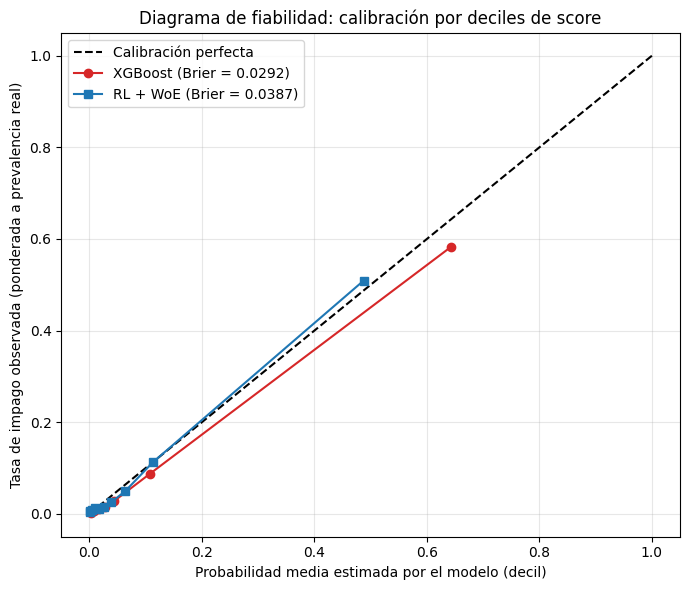

Brier score, ponderado a prevalencia real (menor es mejor):
  XGBoost:                    0.0292
  Regresión Logística + WoE:  0.0387

XGBoost, calibración por decil:
 Prob. media estimada  Tasa real observada  Clientes en el tramo (ponderado)
               0.0020               0.0016                              1833
               0.0036               0.0038                              1825
               0.0055               0.0071                              1831
               0.0081               0.0060                              1835
               0.0116               0.0115                              1827
               0.0178               0.0098                              1830
               0.0270               0.0153                              1834
               0.0440               0.0279                              1827
               0.1069               0.0867                              1833
               0.6433               0.5832                     

In [10]:
from sklearn.metrics import brier_score_loss

# Peso de frecuencia del test: bueno=6, malo=1, igual que en el entrenamiento,
# para que los deciles y las tasas observadas reflejen la prevalencia real (7,5%).
w_test = np.where(y_test == 0, PESO, 1)

def quantil_ponderado(valores, pesos, q):
    orden = np.argsort(valores)
    v, w = valores[orden], pesos[orden]
    cw = (np.cumsum(w) - 0.5 * w) / w.sum()
    return np.interp(q, cw, v)

def calibracion(p, n_bins=10):
    p = np.asarray(p)
    bordes = quantil_ponderado(p, w_test, np.linspace(0, 1, n_bins + 1))
    bordes = np.unique(bordes)
    idx = np.clip(np.digitize(p, bordes[1:-1]), 0, len(bordes) - 2)
    filas = []
    for b in range(len(bordes) - 1):
        mask = idx == b
        if mask.sum() == 0:
            continue
        w_b = w_test[mask]
        filas.append({
            "Prob. media estimada": np.average(p[mask], weights=w_b),
            "Tasa real observada":  np.average(y_test.values[mask], weights=w_b),
            "Clientes en el tramo (ponderado)": w_b.sum(),
        })
    return pd.DataFrame(filas)

cal_xgb   = calibracion(probs_test["XGBoost"])
cal_rlwoe = calibracion(probs_test["Regresión Logística + WoE"])

brier_xgb   = brier_score_loss(y_test, probs_test["XGBoost"], sample_weight=w_test)
brier_rlwoe = brier_score_loss(y_test, probs_test["Regresión Logística + WoE"], sample_weight=w_test)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", label="Calibración perfecta")
ax.plot(cal_xgb["Prob. media estimada"], cal_xgb["Tasa real observada"], "o-",
        color="#d62728", label=f"XGBoost (Brier = {brier_xgb:.4f})")
ax.plot(cal_rlwoe["Prob. media estimada"], cal_rlwoe["Tasa real observada"], "s-",
        color="#1f77b4", label=f"RL + WoE (Brier = {brier_rlwoe:.4f})")
ax.set_xlabel("Probabilidad media estimada por el modelo (decil)")
ax.set_ylabel("Tasa de impago observada (ponderada a prevalencia real)")
ax.set_title("Diagrama de fiabilidad: calibración por deciles de score")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/04_calibracion.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Brier score, ponderado a prevalencia real (menor es mejor):")
print(f"  XGBoost:                    {brier_xgb:.4f}")
print(f"  Regresión Logística + WoE:  {brier_rlwoe:.4f}")
print("\nXGBoost, calibración por decil:")
print(cal_xgb.round(4).to_string(index=False))
print("\nRegresión Logística + WoE, calibración por decil:")
print(cal_rlwoe.round(4).to_string(index=False))

El peso de 6 cumple, en líneas generales, lo que se esperaba de él. En los dos modelos, la probabilidad media estimada y la tasa de impago observada en cada decil están próximas y siguen la diagonal de calibración perfecta a lo largo de todo el rango, desde los deciles de menor riesgo (en torno al 0,1-0,5%) hasta el de mayor riesgo (48-64%). El Brier score, que resume el ajuste global, es bajo en ambos casos: 0,0292 en XGBoost y 0,0387 en la Regresión Logística + WoE, coherente con el mejor poder discriminante del primero.

El ajuste no es perfecto en todos los tramos. En los deciles intermedios (en torno al 2-11% de riesgo estimado), ambos modelos tienden a **sobrestimar** ligeramente el riesgo: por ejemplo, XGBoost estima un 4,4% en un tramo donde la tasa real observada es del 2,8%. La Regresión Logística + WoE muestra el mismo patrón, algo más marcado en los deciles bajos e intermedios, pero se ajusta mejor que XGBoost en los dos extremos (el de menor y el de mayor riesgo). En ningún caso la desviación es de un orden de magnitud, como sí lo era el problema de fuga de información: aquí se trata de un sesgo moderado de sobrestimación en el tramo medio, no de una probabilidad sistemáticamente inservible.

Para el cálculo de la pérdida esperada de Basilea, esto significa que la PD que entrega el modelo es, de partida, una aproximación razonable a la frecuencia real de impago, especialmente en los extremos de la distribución de riesgo, con un margen de prudencia (sobrestimación) en el tramo intermedio que, desde la óptica de la gestión de riesgos, resulta conservador antes que optimista.

## 4.8 Conclusiones de la evaluación

La evaluación se organiza en torno a las cinco propiedades que, según el marco metodológico de Mallo, debe satisfacer un modelo de credit scoring: buen ajuste, capacidad explicativa, poder discriminante, capacidad de clasificación y generalización, a las que se añade aquí la calibración. Las dos primeras se abordaron en los notebooks anteriores (ajuste sobre la muestra de entrenamiento y análisis de la importancia de las variables en el notebook 03, donde se decide además excluir X53 y X48 por sospecha de fuga de información); las restantes se evalúan aquí sobre la muestra de **test**, que no ha intervenido en el entrenamiento. El benchmark de referencia de Mallo se midió sobre su muestra de validación, conjunto estadísticamente equivalente al de test, pero **incluye X53 y X48**: la comparación con él debe leerse teniendo presente esa diferencia de partida, no solo como una diferencia de modelo.

### Poder discriminante

Es la propiedad central en credit scoring y se cuantifica con el AUC, el KS y el Gini:

| Modelo | AUC | KS | Gini |
|--------|-----|----|----|
| Regresión Logística | 0,8886 | 0,6325 | 0,7771 |
| Regresión Logística + WoE | 0,9133 | 0,6909 | 0,8267 |
| Random Forest | 0,9397 | 0,7455 | 0,8794 |
| XGBoost | 0,9422 | 0,7630 | 0,8843 |
| Mallo (referencia, con X53 y X48) | 0,9758 | 0,8897 | 0,9516 |

XGBoost alcanza la mayor capacidad discriminante (AUC 0,9422 y KS 0,7630), seguido muy de cerca por Random Forest. Los dos modelos no lineales superan a los dos lineales por un margen mayor que el que separaba a estos mismos modelos cuando X53 y X48 estaban presentes (notebook 03b): retirar las variables sospechosas no solo reduce el AUC de todos, sino que amplía la ventaja relativa de los ensamblados sobre la recta. Ninguno de los cuatro alcanza el benchmark de Mallo, pero esa distancia es, sobre todo, la distancia que introducen X53 y X48 en su modelo, no una distancia de método.

### Capacidad de clasificación

Fijando el umbral de decisión en 0,5 y expresando la exactitud y el PPV a la prevalencia real de la cartera (92,47% buenos, 7,52% malos):

| Modelo | Exactitud (cartera real) | PPV (cartera real) | Error Tipo I | Error Tipo II |
|--------|------------------|-----|--------------|---------------|
| Regresión Logística | 94,4% | 75,3% | 1,0% | 61,6% |
| Regresión Logística + WoE | 95,3% | 83,5% | 0,7% | 53,9% |
| Random Forest | 96,3% | 81,2% | 1,2% | 34,1% |
| XGBoost | 96,7% | 85,5% | 0,9% | 33,0% |

El error Tipo II (no detectar a un cliente que finalmente impaga) es el más costoso para la entidad, y es donde se concentra la diferencia entre modelos: del 61,6% de la Regresión Logística cruda al 33,0% de XGBoost. Extrapolando estos errores a la cartera completa (67.701 buenos, 5.509 malos), XGBoost dejaría sin detectar del orden de 1.816 impagos y rechazaría por error a unos 624 buenos clientes, frente a los 2.969 y 504, respectivamente, de la Regresión Logística con WoE.

### Generalización

Comparando el AUC de entrenamiento con el de test, la caída es moderada en los modelos no lineales (Random Forest 0,9802 → 0,9397; XGBoost 0,9736 → 0,9422) y prácticamente nula en los lineales. El descenso de Random Forest y XGBoost es mayor que el que mostraban estos mismos modelos con X53 y X48 incluidas, lo que es coherente con lo esperado: al retirar una variable que por sí sola explicaba la mayor parte de los casos, los árboles se apoyan en combinaciones más complejas de señales más débiles, con algo más de margen para ajustarse al ruido de la muestra de entrenamiento. La caída, en cualquier caso, no es abrupta y el AUC de test se mantiene en niveles propios de un buen modelo de scoring, por lo que no hay indicios de sobreajuste severo.

### Calibración

El diagrama de fiabilidad y el Brier score de la sección 4.7 confirman, con matices, lo que el peso de 6 del sobremuestreo pretendía conseguir: probabilidades aproximadamente calibradas a la prevalencia real de la cartera. La probabilidad media estimada y la tasa de impago observada siguen de cerca la diagonal de calibración perfecta en ambos modelos (Brier de 0,0292 en XGBoost y 0,0387 en la Regresión Logística + WoE), con una sobrestimación moderada del riesgo en los tramos intermedios que resulta conservadora antes que optimista para el cálculo de la pérdida esperada.

### Conclusión

Tras excluir X53 y X48 por sospecha de fuga de información (notebook 03), Random Forest y XGBoost mejoran su poder discriminante y su capacidad de clasificación frente a la Regresión Logística, incluida su versión con WoE, y lo hacen con un margen mayor que el observado cuando esas dos variables formaban parte del conjunto. **XGBoost se erige como el modelo recomendado** entre los cuatro evaluados, al combinar el mayor AUC y KS con la menor tasa de error Tipo II, y unas probabilidades razonablemente calibradas para alimentar el cálculo de Basilea II. Ninguno de los cuatro alcanza el AUC de 0,9758 que publica Mallo, y esa distancia es, precisamente, la medida del problema que motivó la revisión: el benchmark de Mallo se apoya en las mismas dos variables que aquí se excluyen. La comparación honesta entre Mallo y este trabajo no es, por tanto, "0,9758 frente a 0,9422", sino la que se desarrolla en el notebook 03 entre los distintos conjuntos de variables, con y sin la sospecha de fuga resuelta.

## 4.9 Importancia de las variables del modelo final

El notebook 03 (sección 3.7) representó la importancia de las variables sobre el conjunto completo de 30 variables, antes de excluir X53 y X48. Se repite aquí esa misma representación sobre Random Forest y XGBoost ya entrenados sobre las 28 variables definitivas, para disponer de la versión correspondiente al modelo final del estudio.

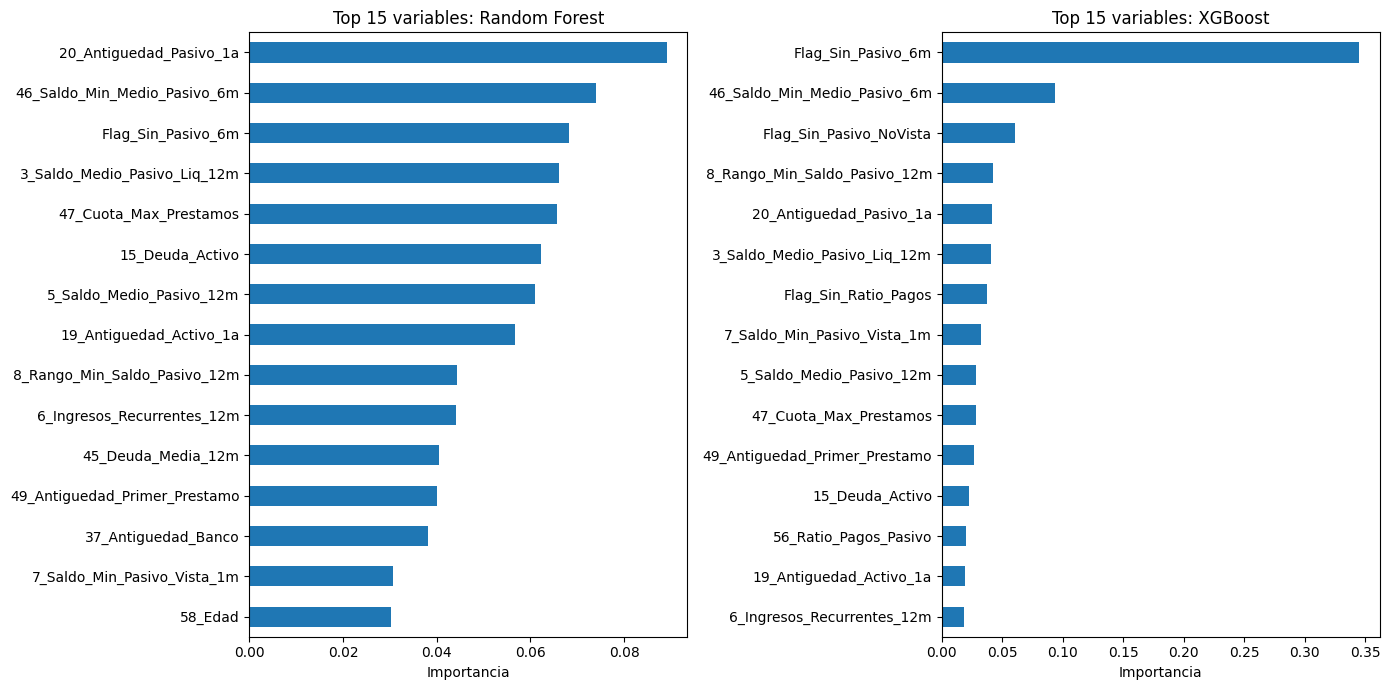

Figura guardada en reports/figures/


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, nombre in [(axes[0], "Random Forest"), (axes[1], "XGBoost")]:
    modelo = modelos[nombre]
    importancias = pd.Series(modelo.feature_importances_, index=FEATURES)
    importancias_top = importancias.nlargest(15).sort_values()
    importancias_top.plot(kind="barh", ax=ax, color="#1f77b4")
    ax.set_title(f"Top 15 variables: {nombre}")
    ax.set_xlabel("Importancia")

plt.tight_layout()
plt.savefig("../reports/figures/04_importancia_variables_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en reports/figures/")